# Weight Uncertainty for Classification

This notebook illustrates IVON's weight uncertainty on a simple classification task.

In [4]:
import torch
import matplotlib.pyplot as plt

from ivon import IVON
from sklearn.datasets import make_moons


plt.rcParams.update(
    {
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman'],
        'axes.labelsize': 8,
        'font.size': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': 'gray',
        'xtick.color': 'gray',
        'ytick.color': 'gray',
        'xtick.major.size': 2,
        'xtick.major.width': 0.5,
        'ytick.major.size': 2,
        'ytick.major.width': 0.5,
        'xtick.minor.size': 1,
        'xtick.minor.width': 0.5,
        'ytick.minor.size': 1,
        'ytick.minor.width': 0.5,
    }
)

%config InlineBackend.figure_format = "svg"

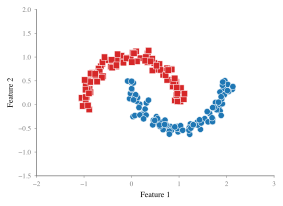

In [5]:
def plot_data(ax, X, y):
    for cls, m, c in [(0, 's', 'tab:red'), (1, 'o', 'tab:blue')]:
        ax.scatter(
            *X[y == cls].T,
            marker=m,
            color=c,
            s=40,
            edgecolors='white',
            linewidths=0.5,
            label=cls,
        )


fig, ax = plt.subplots(figsize=(5 / 1.2, 3.5 / 1.2))

torch.manual_seed(2)

X, y = make_moons(n_samples=200, noise=0.08)
X = torch.as_tensor(X, dtype=torch.float32)
y = torch.as_tensor(y, dtype=torch.float32)
plot_data(ax, X, y)

ax.set(xlabel='Feature 1', ylabel='Feature 2', xlim=(-2, 3), ylim=(-1.5, 2))
ax.set_aspect('equal')
plt.tight_layout()

In [10]:
class MLP(torch.nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        layers = [torch.nn.Linear(2, hidden), torch.nn.ReLU()]
        for _ in range(3):
            layers += [torch.nn.Linear(hidden, hidden), torch.nn.ReLU()]
        layers += [torch.nn.Linear(hidden, 1)]
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = MLP()

opt = IVON(
    model.parameters(),
    lr=0.05,
    ess=1e2,
    weight_decay=1e-5,
    hess_init=0.001,
    beta1=0.9, 
    beta2=0.9995,
    clip_radius=0.5,
    rescale_lr=False
)

steps = 7500
loss_fn = torch.nn.BCEWithLogitsLoss()
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, eta_min=0.0, T_max=steps)

for _ in range(steps + 1):
    with opt.sampled_params(train=True):
        opt.zero_grad()
        loss = loss_fn(model(X), y.view(-1, 1))
        loss.backward()
    opt.step()
    sched.step()

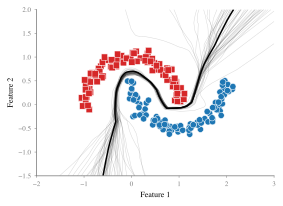

In [11]:
fig, ax = plt.subplots(figsize=(5 / 1.2, 3.5 / 1.2))
plot_data(ax, X, y)
ax.set(xlabel='Feature 1', ylabel='Feature 2', xlim=(-2, 3), ylim=(-1.5, 2))

xx, yy = torch.meshgrid(*[torch.linspace(*lim, 200) for lim in [ax.get_xlim(), ax.get_ylim()]], indexing='xy')
grid = torch.stack([xx.ravel(), yy.ravel()], dim=1)

with torch.no_grad():
    for _ in range(50):
        with opt.sampled_params(train=False):
            zz = model(grid).reshape(xx.shape)
        ax.contour(xx, yy, zz, levels=[0], colors='k', alpha=0.15, linewidths=0.5)

    zz = model(grid).reshape(xx.shape)
    ax.contour(xx, yy, zz, levels=[0], colors='k', linewidths=1.5)

ax.set_aspect('equal')
plt.tight_layout()